In [1]:
import os
import re
from pathlib import Path
from datetime import timedelta
import pandas as pd

def get_tif_size(tif_path: Path):
    try:
        import rasterio
        with rasterio.open(tif_path) as ds:
            return ds.width, ds.height
    except Exception:
        import tifffile
        with tifffile.TiffFile(str(tif_path)) as tf:
            page = tf.pages[0]
            h, w = page.shape[-2], page.shape[-1]
            return w, h

def parse_landsat_datetime_from_mtl(mtl_txt: Path):
    """从 *_MTL.txt 读取 DATE_ACQUIRED + SCENE_CENTER_TIME (UTC)"""
    if mtl_txt is None or (not mtl_txt.exists()):
        return None

    date_acq = None
    scene_time = None
    date_re = re.compile(r"DATE_ACQUIRED\s*=\s*(\d{4}-\d{2}-\d{2})")
    time_re = re.compile(r'SCENE_CENTER_TIME\s*=\s*"?(\d{2}:\d{2}:\d{2}(?:\.\d+)?)(?:Z)?"?')

    with mtl_txt.open("r", errors="ignore") as f:
        for line in f:
            if date_acq is None:
                m = date_re.search(line)
                if m:
                    date_acq = m.group(1)
                    continue
            if scene_time is None:
                m = time_re.search(line)
                if m:
                    scene_time = m.group(1)
                    continue
            if date_acq and scene_time:
                break

    if not (date_acq and scene_time):
        return None

    ts = pd.to_datetime(f"{date_acq}T{scene_time}Z", utc=True, errors="coerce")
    return None if pd.isna(ts) else ts

def parse_landsat_date_from_foldername(folder_name: str):
    """备用：从文件夹名提取采集日期 YYYYMMDD（只有日期，没有时刻）"""
    parts = folder_name.split("_")
    if len(parts) >= 4 and re.fullmatch(r"\d{8}", parts[3]):
        ts = pd.to_datetime(parts[3], format="%Y%m%d", utc=True, errors="coerce")
        return None if pd.isna(ts) else ts
    return None

def find_representative_band_tif(scene_dir: Path):
    cand = sorted(scene_dir.glob("*_SR_B1.TIF"))
    if cand:
        return cand[0]
    cand = sorted(scene_dir.glob("*_SR_B*.TIF"))
    if cand:
        return cand[0]
    return None

def main():
    RAW_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SP")
    MERGED_CSV = Path("../carbon_mapper_data/csvs/merged_file.csv")

    # 你确认一下 merged_file.csv 里，哪个列等于 Landsat 文件夹名（LC08_/LC09_ 开头）
    ID_COL = "plume_id"     # <- 改成你真实的那列名
    TS_COL = "datetime"     # <- 你刚确认的列名

    WINDOW_HOURS = 24

    df = pd.read_csv(MERGED_CSV)
    if ID_COL not in df.columns:
        raise ValueError(f"merged_file.csv 找不到 {ID_COL=}，实际列：{list(df.columns)}")
    if TS_COL not in df.columns:
        raise ValueError(f"merged_file.csv 找不到 {TS_COL=}，实际列：{list(df.columns)}")

    # 你的格式：2019-10-19T14:52:09+00 -> 直接解析成 UTC 时间
    df[TS_COL] = pd.to_datetime(df[TS_COL], utc=True, errors="coerce")
    df = df.dropna(subset=[TS_COL, ID_COL]).copy()

    plume_ts = dict(zip(df[ID_COL].astype(str), df[TS_COL]))

    scene_dirs = [
        p for p in RAW_DIR.iterdir()
        if p.is_dir() and (p.name.startswith("LC08_") or p.name.startswith("LC09_"))
    ]

    rows = []
    missing_plume = 0
    missing_scene_time = 0
    missing_band = 0
    size_fail = 0

    for sd in scene_dirs:
        scene_id = sd.name

        p_ts = plume_ts.get(scene_id)
        if p_ts is None:
            missing_plume += 1

        # 场景时间戳：优先从 *_MTL.txt 读（DATE_ACQUIRED + SCENE_CENTER_TIME）
        mtl = next(iter(sd.glob("*_MTL.txt")), None)
        s_ts = parse_landsat_datetime_from_mtl(mtl)
        if s_ts is None:
            s_ts = parse_landsat_date_from_foldername(scene_id)
        if s_ts is None:
            missing_scene_time += 1

        # 影像尺寸：选一个代表 band（SR_B1 优先）
        band_tif = find_representative_band_tif(sd)
        if band_tif is None:
            missing_band += 1
            w = h = None
        else:
            try:
                w, h = get_tif_size(band_tif)
            except Exception:
                size_fail += 1
                w = h = None

        # 24h 判断：plume 之后 24 小时内 (0 <= scene - plume <= 24h)
        in_24h = None
        delta_hours = None
        if (p_ts is not None) and (s_ts is not None):
            dt = s_ts - p_ts
            delta_hours = dt.total_seconds() / 3600.0
            in_24h = (0.0 <= delta_hours <= WINDOW_HOURS)

        rows.append({
            "scene_id": scene_id,
            "plume_ts_utc": None if p_ts is None else p_ts.isoformat(),
            "scene_ts_utc": None if s_ts is None else s_ts.isoformat(),
            "delta_hours": delta_hours,
            "in_24h_after_plume": in_24h,
            "sample_band_tif": None if band_tif is None else str(band_tif),
            "width": w,
            "height": h,
        })

    out = pd.DataFrame(rows)

    # --- 统计 24h ---
    matchable = out.dropna(subset=["in_24h_after_plume"])
    n_in_24h = int((matchable["in_24h_after_plume"] == True).sum())
    n_matchable = len(matchable)

    # --- 尺寸统计 ---
    size_df = out.dropna(subset=["width", "height"]).copy()
    if len(size_df) > 0:
        size_df["area"] = size_df["width"] * size_df["height"]
        w_stats = size_df["width"].describe()
        h_stats = size_df["height"].describe()
    else:
        w_stats = h_stats = None

    print("==== Scan summary ====")
    print(f"Total scene folders scanned: {len(scene_dirs)}")
    print(f"Folders missing plume timestamp match (no {ID_COL} in merged_file): {missing_plume}")
    print(f"Folders missing scene time (MTL + folder fallback both failed): {missing_scene_time}")
    print(f"Folders missing SR band tif: {missing_band}")
    print(f"Folders failed to read size: {size_fail}")

    print("\n==== 24h after plume ====")
    print(f"Matchable (have both plume_ts and scene_ts): {n_matchable}")
    print(f"In 0~{WINDOW_HOURS} hours after plume: {n_in_24h}")
    if n_matchable > 0:
        print(f"Ratio: {n_in_24h / n_matchable:.4f}")

    print("\n==== Image size (W,H) stats (from sample SR band) ====")
    if w_stats is not None:
        print("Width stats:\n", w_stats.to_string())
        print("Height stats:\n", h_stats.to_string())
        print(f"Min (W,H): ({int(size_df['width'].min())}, {int(size_df['height'].min())})")
        print(f"Max (W,H): ({int(size_df['width'].max())}, {int(size_df['height'].max())})")
        print(f"Mean (W,H): ({size_df['width'].mean():.2f}, {size_df['height'].mean():.2f})")
    else:
        print("No readable TIF sizes found.")

    # 可选：保存每个文件夹的详细结果
    out_csv = RAW_DIR / "l89_scene_plume_24h_and_size_report.csv"
    out.to_csv(out_csv, index=False)
    print(f"\nSaved per-scene report to: {out_csv}")

if __name__ == "__main__":
    main()


==== Scan summary ====
Total scene folders scanned: 7858
Folders missing plume timestamp match (no plume_id in merged_file): 7858
Folders missing scene time (MTL + folder fallback both failed): 0
Folders missing SR band tif: 126
Folders failed to read size: 0

==== 24h after plume ====
Matchable (have both plume_ts and scene_ts): 0
In 0~24 hours after plume: 0

==== Image size (W,H) stats (from sample SR band) ====
Width stats:
 count    7732.000000
mean     7701.949302
std       120.710307
min      7501.000000
25%      7611.000000
50%      7681.000000
75%      7761.000000
max      8891.000000
Height stats:
 count    7732.000000
mean     7826.209519
std       108.518296
min      7661.000000
25%      7741.000000
50%      7811.000000
75%      7891.000000
max      8921.000000
Min (W,H): (7501, 7661)
Max (W,H): (8891, 8921)
Mean (W,H): (7701.95, 7826.21)

Saved per-scene report to: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SP/l89_scene_plume_24h_and_size_repor

In [1]:
import os
import pandas as pd

ROOT = "/data2/yuyao/methane_emission/carbonmapper_data_l89_l2sp_90360"
OUT_CSV = "plume_l89_90360_index.csv"

rows = []

for plume_id in sorted(os.listdir(ROOT)):
    plume_dir = os.path.join(ROOT, plume_id)
    if not os.path.isdir(plume_dir):
        continue
    if not plume_id.startswith("ang"):
        continue

    minus90 = None
    minus360 = None

    for fn in os.listdir(plume_dir):
        if not fn.endswith(".tif"):
            continue
        if "minus90" in fn:
            minus90 = fn
        elif "minus360" in fn:
            minus360 = fn

    rows.append({
        "plume_id": plume_id,
        "l89_minus90": minus90,
        "l89_minus360": minus360,
    })

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
print(df.head())

Saved: plume_l89_90360_index.csv
               plume_id                           l89_minus90  \
0  ang20160910t185702-A  l8_minus90_LC80410362016158LGN01.tif   
1  ang20160910t191651-A  l8_minus90_LC80410362016158LGN01.tif   
2  ang20160910t192242-A  l8_minus90_LC80410362016158LGN01.tif   
3  ang20160910t193531-A  l8_minus90_LC80410362016158LGN01.tif   
4  ang20160910t193531-B  l8_minus90_LC80410362016158LGN01.tif   

                            l89_minus360  
0  l8_minus360_LC80410362015267LGN01.tif  
1  l8_minus360_LC80410362015267LGN01.tif  
2  l8_minus360_LC80410362015267LGN01.tif  
3  l8_minus360_LC80410362015267LGN01.tif  
4  l8_minus360_LC80410362015267LGN01.tif  


In [2]:
import os
import pandas as pd

ROOT = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SP_90360"
OUT = "landsat_l2sp_audit_sr_only.csv"

rows = []

for scene in sorted(os.listdir(ROOT)):
    scene_dir = os.path.join(ROOT, scene)
    if not os.path.isdir(scene_dir):
        continue

    sr_files = []
    st_files = []

    for fn in os.listdir(scene_dir):
        if fn.lower().endswith(".tif"):
            if "_SR_" in fn:
                sr_files.append(fn)
            elif "_ST_" in fn:
                st_files.append(fn)

    # 🚨 丢弃没有 SR 的 scene
    if len(sr_files) == 0:
        continue

    sr_files = sorted(sr_files)
    st_files = sorted(st_files)

    rows.append({
        "scene_id": scene,
        "num_SR_bands": len(sr_files),
        "num_ST_bands": len(st_files),
        "SR_files": ";".join([os.path.join(scene_dir, f) for f in sr_files]),
        "ST_files": ";".join([os.path.join(scene_dir, f) for f in st_files]),
    })

df = pd.DataFrame(rows)
df.to_csv(OUT, index=False)

print("Saved:", OUT)
print("Valid SR scenes:", len(df))
print(df.head())


Saved: landsat_l2sp_audit_sr_only.csv
Valid SR scenes: 407
                                   scene_id  num_SR_bands  num_ST_bands  \
0  LC08_L2SP_003071_20220731_20220805_02_T1             8             9   
1  LC08_L2SP_017032_20220818_20220823_02_T1             8             9   
2  LC08_L2SP_021037_20221102_20221114_02_T1             8             9   
3  LC08_L2SP_030038_20221101_20221114_02_T1             8             9   
4  LC08_L2SP_032037_20210808_20210819_02_T1             8             9   

                                            SR_files  \
0  /mnt/engg-leung/Research_No9_Methane_Emissions...   
1  /mnt/engg-leung/Research_No9_Methane_Emissions...   
2  /mnt/engg-leung/Research_No9_Methane_Emissions...   
3  /mnt/engg-leung/Research_No9_Methane_Emissions...   
4  /mnt/engg-leung/Research_No9_Methane_Emissions...   

                                            ST_files  
0  /mnt/engg-leung/Research_No9_Methane_Emissions...  
1  /mnt/engg-leung/Research_No9_Methane_Emi

In [3]:
import os
from pathlib import Path
import pandas as pd

# ====== paths ======
MERGED_CSV = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv"
L89_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SR_by_gee")
OUT_CSV = "merged_plumes_with_l89_sr.csv"

# ====== load merged plume ids ======
merged = pd.read_csv(MERGED_CSV)
if "plume_id" not in merged.columns:
    raise RuntimeError(f"`plume_id` not found in {MERGED_CSV}. columns={list(merged.columns)}")

plume_set = set(merged["plume_id"].astype(str).tolist())

# ====== scan tif files and parse plume_id from filename ======
rows = []
for p in sorted(L89_DIR.glob("*.tif")):
    name = p.name

    # expected: <plume_id>_l89_sr_LANDSAT_8_YYYYMMDDTHHMMSSZ.tif
    key = "_l89_sr_"
    if key not in name:
        continue

    plume_id = name.split(key)[0]  # everything before "_l89_sr_"
    if plume_id in plume_set:
        rows.append({
            "plume_id": plume_id,
            "l89_path": str(p),
            "l89_filename": name,
        })

df = pd.DataFrame(rows)

# 如果同一个 plume_id 有多个文件（极少数情况），保留全部；你也可以改成只保留最新/第一个
df.to_csv(OUT_CSV, index=False)

print("Saved:", OUT_CSV)
print("Matched plumes:", df["plume_id"].nunique(), " / files:", len(df))
print(df.head(10))


Saved: merged_plumes_with_l89_sr.csv
Matched plumes: 2650  / files: 2650
                    plume_id  \
0  GAO20191022t151126p0000-D   
1  GAO20191022t151126p0000-F   
2  GAO20191022t151126p0000-G   
3  GAO20191022t151126p0000-H   
4  GAO20191022t154327p0000-E   
5  GAO20191022t154327p0000-G   
6  GAO20191022t154327p0000-H   
7  GAO20191022t154327p0000-I   
8  GAO20191022t154327p0000-J   
9  GAO20191031t160141p0000-A   

                                            l89_path  \
0  /mnt/engg-leung/Research_No9_Methane_Emissions...   
1  /mnt/engg-leung/Research_No9_Methane_Emissions...   
2  /mnt/engg-leung/Research_No9_Methane_Emissions...   
3  /mnt/engg-leung/Research_No9_Methane_Emissions...   
4  /mnt/engg-leung/Research_No9_Methane_Emissions...   
5  /mnt/engg-leung/Research_No9_Methane_Emissions...   
6  /mnt/engg-leung/Research_No9_Methane_Emissions...   
7  /mnt/engg-leung/Research_No9_Methane_Emissions...   
8  /mnt/engg-leung/Research_No9_Methane_Emissions...   
9  /mnt/engg-l

In [2]:
import os
import re
import random
from pathlib import Path

import numpy as np
import pandas as pd

# 需要：rasterio, pyproj
import rasterio
from rasterio.warp import transform as rio_transform
from pyproj import Geod

# ======================
# Config
# ======================
DATA_DIR = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SR_by_gee"
PLUME_CSV = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv"

SAMPLE_N = 500          # 先抽 500 个；你也可以改成 200 / 1000
SEED = 42

EXPECTED_SIZE = 512     # 你期望的 chip 尺寸
BAD_PX_THRESH = 32      # 偏移超过 32 px 先算明显可疑（可改 16/64）
OUT_CSV = "l89_qc_report.csv"

# ======================
# Helpers
# ======================
geod = Geod(ellps="WGS84")

def parse_plume_id_from_filename(p: str):
    """
    你的文件名格式：{plume_id}_l89_sr_{SPACECRAFT}_{YYYY...}.tif
    所以取 "_l89_sr_" 之前作为 plume_id
    """
    base = os.path.basename(p)
    if "_l89_sr_" not in base:
        return None
    return base.split("_l89_sr_", 1)[0].strip()

def meters_between(lon1, lat1, lon2, lat2):
    # 返回大地线距离（米）
    _, _, dist = geod.inv(lon1, lat1, lon2, lat2)
    return float(dist)

def center_lonlat_of_raster(ds: rasterio.DatasetReader):
    """
    取影像中心像素的地理坐标，再转换到 EPSG:4326 (lon,lat)
    """
    h = ds.height
    w = ds.width
    # 中心像素（行列）
    row = h / 2.0
    col = w / 2.0
    x, y = ds.transform * (col, row)  # 注意 rasterio 里 transform * (col,row)
    if ds.crs is None:
        return None, None
    lon, lat = rio_transform(ds.crs, "EPSG:4326", [x], [y])
    return float(lon[0]), float(lat[0])

def approx_pixel_size_m(ds: rasterio.DatasetReader):
    """
    粗略取像素大小（米）。对投影坐标（UTM 等）很准；若是经纬度则会不准。
    """
    a = ds.transform.a
    e = ds.transform.e
    # e 一般为负，取绝对值
    return float(abs(a)), float(abs(e))

def find_all_tifs(root: str):
    root = Path(root)
    tifs = []
    for p in root.rglob("*.tif"):
        tifs.append(str(p))
    return tifs

def summarize_series(name, arr):
    arr = np.array([x for x in arr if np.isfinite(x)], dtype=float)
    if arr.size == 0:
        return f"{name}: (empty)"
    qs = np.percentile(arr, [50, 75, 90, 95, 99])
    return (f"{name}: n={arr.size} | "
            f"p50={qs[0]:.2f}, p75={qs[1]:.2f}, p90={qs[2]:.2f}, "
            f"p95={qs[3]:.2f}, p99={qs[4]:.2f}")

# ======================
# Main
# ======================
def main():
    print("[1/5] loading plume csv ...")
    df = pd.read_csv(PLUME_CSV)
    need_cols = {"plume_id", "plume_latitude", "plume_longitude"}
    missing = need_cols - set(df.columns)
    if missing:
        raise RuntimeError(f"merged_file.csv missing columns: {missing}")
    df["plume_id"] = df["plume_id"].astype(str)
    plume_map = df.set_index("plume_id")[["plume_latitude", "plume_longitude"]].to_dict("index")
    print(f"  plumes in csv: {len(plume_map)}")

    print("[2/5] scanning tif files ...")
    tifs = find_all_tifs(DATA_DIR)
    print(f"  found tif: {len(tifs)}")
    if len(tifs) == 0:
        print("No tif found. Exit.")
        return

    random.seed(SEED)
    if len(tifs) > SAMPLE_N:
        sample_paths = random.sample(tifs, SAMPLE_N)
    else:
        sample_paths = tifs

    print(f"[3/5] sampling {len(sample_paths)} and analyzing ...")

    records = []
    bad_shape = 0
    missing_plume = 0
    no_crs = 0

    for i, p in enumerate(sample_paths, 1):
        plume_id = parse_plume_id_from_filename(p)
        if plume_id is None:
            continue

        meta = plume_map.get(plume_id)
        if meta is None or pd.isna(meta["plume_latitude"]) or pd.isna(meta["plume_longitude"]):
            missing_plume += 1
            continue
        pl_lat = float(meta["plume_latitude"])
        pl_lon = float(meta["plume_longitude"])

        try:
            with rasterio.open(p) as ds:
                h, w = ds.height, ds.width
                count = ds.count
                crs = str(ds.crs) if ds.crs else None
                if crs is None:
                    no_crs += 1

                # shape check
                shape_ok = (h == EXPECTED_SIZE and w == EXPECTED_SIZE)
                if not shape_ok:
                    bad_shape += 1

                cen_lon, cen_lat = center_lonlat_of_raster(ds)
                if cen_lon is None:
                    dist_m = np.nan
                    dist_px = np.nan
                else:
                    dist_m = meters_between(pl_lon, pl_lat, cen_lon, cen_lat)

                    # px distance: 用像素大小粗略折算
                    px_x_m, px_y_m = approx_pixel_size_m(ds)
                    # 如果是经纬度 CRS，这个会很怪；但多数 Landsat 导出应是投影坐标
                    px_m = float(np.mean([px_x_m, px_y_m])) if (px_x_m > 0 and px_y_m > 0) else np.nan
                    dist_px = dist_m / px_m if np.isfinite(px_m) and px_m > 0 else np.nan

                records.append({
                    "path": p,
                    "plume_id": plume_id,
                    "bands": count,
                    "height": h,
                    "width": w,
                    "shape_ok": shape_ok,
                    "crs": crs,
                    "pixel_size_x": ds.transform.a,
                    "pixel_size_y": ds.transform.e,
                    "center_lon": cen_lon,
                    "center_lat": cen_lat,
                    "plume_lon": pl_lon,
                    "plume_lat": pl_lat,
                    "center_offset_m": dist_m,
                    "center_offset_px": dist_px,
                })
        except Exception as e:
            records.append({
                "path": p,
                "plume_id": plume_id,
                "error": repr(e),
            })

        if i % 50 == 0:
            print(f"  analyzed {i}/{len(sample_paths)} ...", flush=True)

    out = pd.DataFrame(records)

    print("[4/5] summary ...")
    print(f"  total analyzed rows: {len(out)}")
    if "error" in out.columns:
        err_cnt = out["error"].notna().sum()
        print(f"  read errors: {err_cnt}")

    if "shape_ok" in out.columns:
        print(f"  shape_ok rate: {out['shape_ok'].mean():.3f}  (expected {EXPECTED_SIZE}x{EXPECTED_SIZE})")

    if "center_offset_px" in out.columns:
        px = out["center_offset_px"].dropna().values
        m = out["center_offset_m"].dropna().values
        print(" ", summarize_series("center_offset_px", px))
        print(" ", summarize_series("center_offset_m", m))

        # 可疑比例
        bad = out["center_offset_px"].dropna() > BAD_PX_THRESH
        print(f"  suspicious (offset_px > {BAD_PX_THRESH}): {bad.mean():.3f}")

    print(f"  missing plume_id in csv (during sampling): {missing_plume}")
    print(f"  no crs: {no_crs}")
    print(f"  bad shape count: {bad_shape}")

    # 排序：最坏的在前
    if "center_offset_px" in out.columns:
        out_sorted = out.sort_values(by=["shape_ok", "center_offset_px"], ascending=[True, False])
    else:
        out_sorted = out

    out_sorted.to_csv(OUT_CSV, index=False)
    print(f"[5/5] saved report: {OUT_CSV}")

    # 打印最坏的 20 个给你肉眼看
    if "center_offset_px" in out_sorted.columns:
        top = out_sorted.dropna(subset=["center_offset_px"]).head(20)
        print("\nWorst 20 samples:")
        for _, r in top.iterrows():
            print(f"  px={r['center_offset_px']:.2f}  m={r['center_offset_m']:.1f}  shape_ok={r.get('shape_ok')}  {r['path']}")

if __name__ == "__main__":
    main()


[1/5] loading plume csv ...
  plumes in csv: 24470
[2/5] scanning tif files ...
  found tif: 2650
[3/5] sampling 500 and analyzing ...
  analyzed 50/500 ...
  analyzed 100/500 ...
  analyzed 150/500 ...
  analyzed 200/500 ...
  analyzed 250/500 ...
  analyzed 300/500 ...
  analyzed 350/500 ...
  analyzed 400/500 ...
  analyzed 450/500 ...
  analyzed 500/500 ...
[4/5] summary ...
  total analyzed rows: 500
  shape_ok rate: 0.008  (expected 512x512)
  center_offset_px: n=500 | p50=0.48, p75=0.68, p90=0.84, p95=0.94, p99=1.07
  center_offset_m: n=500 | p50=14.52, p75=20.55, p90=25.21, p95=28.17, p99=32.21
  suspicious (offset_px > 32): 0.000
  missing plume_id in csv (during sampling): 0
  no crs: 0
  bad shape count: 496
[5/5] saved report: l89_qc_report.csv

Worst 20 samples:
  px=1.26  m=37.8  shape_ok=False  /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SR_by_gee/ang20220324t195537-E_l89_sr_LANDSAT_8_20220325T175015Z.tif
  px=1.16  m=34.7  shape_ok=False  /mn

In [3]:
import pandas as pd
df = pd.read_csv("l89_qc_report.csv")
print(df[['height','width']].value_counts().head(20))

height  width
516     515      35
520     519      24
514     513      23
517     516      21
526     525      21
516     516      20
521     520      18
519     518      17
522     521      16
525     524      14
527     526      14
519     519      13
523     522      12
528     527      11
530     529      10
531     530      10
517     517      10
525     523      10
513     512      10
518     517       9
Name: count, dtype: int64


In [5]:
# fix_l89_make_512_dataset.py
import os
import re
from pathlib import Path
import numpy as np
import pandas as pd
import tifffile as tiff
from tqdm import tqdm

# =========================
# Config
# =========================
CSV_IN = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv"
L89_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SR_by_gee")

OUT_BASE_DIR = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_l89_fixed_512")
OUT_BASE_DIR.mkdir(parents=True, exist_ok=True)
CSV_OUT = OUT_BASE_DIR / "l89_fixed_512.csv"

PATCH = 512
OUT_L89_512 = "l89_512.tif"

# CSV field candidates
LAT_CANDIDATES = ["plume_latitude", "latitude", "lat", "center_lat"]
LON_CANDIDATES = ["plume_longitude", "longitude", "lon", "center_lon"]
ID_CANDIDATES  = ["plume_id", "id", "sample_id"]

# =========================
# Helpers
# =========================
def pick_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def to_chw(arr):
    if arr.ndim == 2:
        return arr[None, :, :]
    if arr.ndim != 3:
        raise ValueError(f"Unexpected ndim={arr.ndim}, shape={arr.shape}")
    # Landsat 导出通常是 (bands,H,W) 或 (H,W,bands)
    if arr.shape[0] <= 32 and arr.shape[1] > 64 and arr.shape[2] > 64:
        return arr  # CHW
    return np.transpose(arr, (2, 0, 1))  # HWC -> CHW

def center_crop_or_pad(chw, target=512):
    c, h, w = chw.shape
    out = np.zeros((c, target, target), dtype=chw.dtype)

    # 输入窗口
    y0_in = max(0, (h - target) // 2)
    x0_in = max(0, (w - target) // 2)
    y1_in = min(h, y0_in + target)
    x1_in = min(w, x0_in + target)

    crop = chw[:, y0_in:y1_in, x0_in:x1_in]
    hh, ww = crop.shape[1], crop.shape[2]

    # 输出放置（如果需要 pad）
    y0_out = (target - hh) // 2
    x0_out = (target - ww) // 2
    out[:, y0_out:y0_out+hh, x0_out:x0_out+ww] = crop
    return out

def parse_plume_id_from_name(name: str):
    # {plume_id}_l89_sr_...
    if "_l89_sr_" not in name:
        return None
    return name.split("_l89_sr_", 1)[0].strip()

def parse_acq_time_from_name(name: str):
    # ..._YYYYmmddTHHMMSSZ.tif
    m = re.search(r"_(\d{8}T\d{6}Z)\.tif$", name)
    return m.group(1) if m else ""

def build_l89_index(l89_dir: Path):
    """
    返回 dict: plume_id -> best_path
    如果同一 plume_id 多张，选 acq_time 字符串最大的（通常就是最新）
    """
    best = {}
    for p in l89_dir.rglob("*.tif"):
        n = p.name
        pid = parse_plume_id_from_name(n)
        if not pid:
            continue
        t = parse_acq_time_from_name(n)
        if pid not in best:
            best[pid] = (t, str(p))
        else:
            if t > best[pid][0]:
                best[pid] = (t, str(p))
    return {k: v[1] for k, v in best.items()}

# =========================
# Main
# =========================
df = pd.read_csv(CSV_IN)

lat_col = pick_first_existing_col(df, LAT_CANDIDATES)
lon_col = pick_first_existing_col(df, LON_CANDIDATES)
id_col  = pick_first_existing_col(df, ID_CANDIDATES)
if id_col is None:
    raise ValueError(f"CSV 缺少 ID 列：{ID_CANDIDATES}")
if lat_col is None or lon_col is None:
    raise ValueError(f"CSV 缺少经纬度列：lat in {LAT_CANDIDATES}, lon in {LON_CANDIDATES}")

df[id_col] = df[id_col].astype(str)

print("[index] scanning L89 directory ...")
l89_map = build_l89_index(L89_DIR)
print(f"[index] found plume_id with L89 tif: {len(l89_map)} (total df={len(df)})")

df["l89_path_raw"] = None
df["l89_path_512"] = None

missing = 0
written = 0

for idx, row in tqdm(df.iterrows(), total=len(df), desc="L89 -> fixed 512"):
    pid = str(row[id_col])
    src_path = l89_map.get(pid)
    if not src_path or not os.path.exists(src_path):
        missing += 1
        continue

    out_dir = OUT_BASE_DIR / pid
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / OUT_L89_512

    df.at[idx, "l89_path_raw"] = src_path

    if not out_path.exists():
        arr = tiff.imread(src_path)
        chw = to_chw(arr)
        fixed = center_crop_or_pad(chw, PATCH)
        tiff.imwrite(str(out_path), fixed, compression="zlib")
        written += 1

    df.at[idx, "l89_path_512"] = str(out_path)

df.to_csv(CSV_OUT, index=False)

print("\n========== DONE ==========")
print("OUT_BASE_DIR:", OUT_BASE_DIR)
print("CSV_OUT:", CSV_OUT)
print("missing L89 tif:", missing)
print("new written:", written)


[index] scanning L89 directory ...
[index] found plume_id with L89 tif: 2650 (total df=24470)


L89 -> fixed 512: 100%|██████████| 24470/24470 [11:30<00:00, 35.42it/s] 



========== DONE ==========
OUT_BASE_DIR: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_l89_fixed_512
CSV_OUT: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_l89_fixed_512/l89_fixed_512.csv
missing L89 tif: 21820
new written: 2650


In [8]:
df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_l89_fixed_512/l89_fixed_512.csv")
df=df.dropna(subset=["l89_path_512"])
df.to_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_l89_fixed_512/l89_fixed_512.csv", index=False)
print(len(df))

2650


/tmp/ipykernel_1869455/752977702.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_l89_fixed_512/l89_fixed_512.csv")


In [24]:
# split_l89_train_test.py
import pandas as pd

all_csv = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_l89_fixed_512/l89_fixed_512.csv"
df = pd.read_csv(all_csv)

df["date"] = pd.to_datetime(df["datetime"])
train_df = df[(df["date"] < "2024-06-20")]
test_df  = df[(df["date"] >= "2024-06-20")& (df["date"] < "2024-12-01")]

print(f"training set {len(train_df)} testing set {len(test_df)} train ratio {len(train_df)/(len(train_df)+len(test_df)):.4f}")

train_csv = "/data2/yuyao/methane_emission/data_csv/l89_temporal_split2024/train.csv"
test_csv  = "/data2/yuyao/methane_emission/data_csv/l89_temporal_split2024/test.csv"

train_df.to_csv(train_csv, index=False)
test_df.to_csv(test_csv, index=False)

print("train_csv:", train_csv)
print("test_csv:", test_csv)


training set 1504 testing set 203 train ratio 0.8811
train_csv: /data2/yuyao/methane_emission/data_csv/l89_temporal_split2024/train.csv
test_csv: /data2/yuyao/methane_emission/data_csv/l89_temporal_split2024/test.csv


In [25]:
# build_l89_32_dataset.py
import os
import pandas as pd
import numpy as np
import tifffile
import random
import threading
from concurrent.futures import ThreadPoolExecutor
import math

base_dir = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_l89_32_fixed_512_2024"
train_csv_path = os.path.join(base_dir, "train.csv")
test_csv_path  = os.path.join(base_dir, "test.csv")

origin_train_csv = "/data2/yuyao/methane_emission/data_csv/l89_temporal_split2024/train.csv"
origin_test_csv  = "/data2/yuyao/methane_emission/data_csv/l89_temporal_split2024/test.csv"

os.makedirs(base_dir, exist_ok=True)

image_size = 32
H512 = 512
W512 = 512

# Landsat SR 波段通常 7 + QA 3 = 10 bands（你导出是 SR_B1..B7 + QA_PIXEL + QA_RADSAT + SR_QA_AEROSOL）
# 这里不做 band12 zero_ratio 了；如果你想做，可以改为某个 SR band (比如 SR_B5) 的 zero_ratio
ZERO_RATIO_THRESH = 0.20
CHECK_BAND_INDEX = 0  # 可选：检查第1个band的零值比例

N_POS = 16
N_NEG = 16

def to_chw(data):
    if data.ndim == 2:
        return data[None, :, :]
    if data.ndim != 3:
        return None
    # L89：可能是 CHW 或 HWC
    if data.shape[0] <= 32 and data.shape[1] > 64 and data.shape[2] > 64:
        return data
    return data.transpose(2, 0, 1)

def get_crop(width=512, height=512, center_size=20, crop_width=32):
    center_x = width // 2
    center_y = height // 2
    center_left   = center_x - center_size // 2
    center_right  = center_x + center_size // 2
    center_top    = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    left_min = max(0, center_right - crop_width)
    left_max = min(center_left, width - crop_width)
    top_min  = max(0, center_bottom - crop_width)
    top_max  = min(center_top, height - crop_width)

    x = random.randint(left_min, left_max)
    y = random.randint(top_min, top_max)
    return x, y

def is_center_contained(crop_xy, image_size=32, width=512, height=512, center_size=10):
    center_x = width // 2
    center_y = height // 2
    cx1 = center_x - center_size // 2
    cy1 = center_y - center_size // 2
    cx2 = center_x + center_size // 2
    cy2 = center_y + center_size // 2

    x, y = crop_xy
    x1, y1 = x, y
    x2, y2 = x + image_size, y + image_size
    return (x1 <= cx1 and y1 <= cy1 and x2 >= cx2 and y2 >= cy2)

class ThreadSafeCounter:
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter

def zero_too_much(arr_chw, band_index=0):
    if arr_chw is None:
        return True
    if band_index >= arr_chw.shape[0]:
        return False
    band = arr_chw[band_index]
    total = band.size
    if total == 0:
        return True
    return (np.sum(band == 0) / total) >= ZERO_RATIO_THRESH

def crop_chw(arr_chw, crop_xy, size):
    x, y = crop_xy
    return arr_chw[:, y:y+size, x:x+size]

def process_row(row, index, total_count, output_cnt, pos_cnt):
    p = row.get("l89_path_512", None)
    if not isinstance(p, str) or not os.path.exists(p):
        return []

    t_data = to_chw(tifffile.imread(p))
    if t_data is None:
        return []
    if t_data.shape[-2:] != (H512, W512):
        # 防御：如果没修好512就跳
        return []

    data = []
    dummy_mask = np.zeros((image_size, image_size), dtype=np.uint8)

    # 正样本：包含中心
    crop_list = [get_crop(crop_width=image_size) for _ in range(N_POS)]
    for crop_xy in crop_list:
        nt = crop_chw(t_data, crop_xy, image_size)
        if nt.shape[-2:] != (image_size, image_size):
            continue
        if zero_too_much(nt, CHECK_BAND_INDEX):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "l89.tif")
        mask_path = os.path.join(dir_path, "plume.tif")
        tifffile.imwrite(nt_path, nt)
        tifffile.imwrite(mask_path, dummy_mask)

        data.append({
            "id": cnt,
            "image_path": nt_path,
            "plume_mask_path": mask_path,
            "label": 1,
            "plume_id": row.get("plume_id", None),
            "latitude": row.get("plume_latitude", None),
            "longitude": row.get("plume_longitude", None),
            "datetime": row.get("datetime", None),
        })
        pos_cnt.increment()

    # 负样本：随机（不包含中心）
    for _ in range(N_NEG):
        crop_xy = (random.randint(0, W512 - image_size), random.randint(0, H512 - image_size))
        nt = crop_chw(t_data, crop_xy, image_size)
        if nt.shape[-2:] != (image_size, image_size):
            continue
        if zero_too_much(nt, CHECK_BAND_INDEX):
            continue

        is_pos = is_center_contained(crop_xy, image_size=image_size)
        label = 1 if is_pos else 0

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "l89.tif")
        mask_path = os.path.join(dir_path, "plume.tif")
        tifffile.imwrite(nt_path, nt)
        tifffile.imwrite(mask_path, dummy_mask)

        data.append({
            "id": cnt,
            "image_path": nt_path,
            "plume_mask_path": mask_path,
            "label": label,
            "plume_id": row.get("plume_id", None),
            "latitude": row.get("plume_latitude", None),
            "longitude": row.get("plume_longitude", None),
            "datetime": row.get("datetime", None),
        })
        if is_pos:
            pos_cnt.increment()

    print(f"processed {index}/{total_count} pos_cnt={pos_cnt.get()} out_cnt={output_cnt.get()}")
    return data

def run_split(csv_path, out_csv_path, output_cnt, pos_cnt):
    org_df = pd.read_csv(csv_path)
    data_all = []

    batch_size = 32
    total_rows = len(org_df)
    num_batches = math.ceil(total_rows / batch_size)

    for batch_num in range(num_batches):
        batch_df = org_df.iloc[batch_num*batch_size : min((batch_num+1)*batch_size, total_rows)]

        futures = []
        with ThreadPoolExecutor(max_workers=16) as executor:
            for index, row in batch_df.iterrows():
                futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, pos_cnt))
            for future in futures:
                data_all.extend(future.result())

    out_df = pd.DataFrame(data_all)
    out_df.to_csv(out_csv_path, index=False)
    print(f"wrote {out_csv_path}, size={len(out_df)} label_sum={out_df['label'].sum() if len(out_df)>0 else 0}")
    return out_df

output_cnt = ThreadSafeCounter()
pos_cnt = ThreadSafeCounter()

train_df = run_split(origin_train_csv, train_csv_path, output_cnt, pos_cnt)
test_df  = run_split(origin_test_csv, test_csv_path, output_cnt, pos_cnt)

print(f"total count: {len(train_df) + len(test_df)}")
print(f"train label sum: {train_df['label'].sum()} / {len(train_df)}")
print(f"test label sum: {test_df['label'].sum()} / {len(test_df)}")


processed 4/1504 pos_cnt=1 out_cnt=8
processed 0/1504 pos_cnt=2 out_cnt=11
processed 6/1504 pos_cnt=2 out_cnt=15
processed 3/1504 pos_cnt=17 out_cnt=40
processed 5/1504 pos_cnt=49 out_cnt=75
processed 1/1504 pos_cnt=252 out_cnt=355
processed 7/1504 pos_cnt=252 out_cnt=363
processed 2/1504 pos_cnt=268 out_cnt=497
processed 11/1504 pos_cnt=268 out_cnt=500
processed 14/1504 pos_cnt=270 out_cnt=509
processed 12/1504 pos_cnt=270 out_cnt=511
processed 9/1504 pos_cnt=270 out_cnt=517
processed 8/1504 pos_cnt=271 out_cnt=518
processed 15/1504 pos_cnt=274 out_cnt=522
processed 18/1504 pos_cnt=274 out_cnt=522
processed 10/1504 pos_cnt=275 out_cnt=529
processed 13/1504 pos_cnt=275 out_cnt=529
processed 16/1504 pos_cnt=275 out_cnt=529
processed 17/1504 pos_cnt=282 out_cnt=537
processed 19/1504 pos_cnt=294 out_cnt=552
processed 20/1504 pos_cnt=314 out_cnt=574
processed 21/1504 pos_cnt=430 out_cnt=772
processed 22/1504 pos_cnt=430 out_cnt=775
processed 23/1504 pos_cnt=430 out_cnt=846
processed 26/150

In [1]:
import rasterio
import pandas as pd

file="/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SR_by_gee/GAO20191022t151126p0000-D_l89_sr_LANDSAT_8_20191022T173354Z.tif"
with rasterio.open(file) as ds:
    print(ds.width, ds.height)
    print(ds.crs)
    print(ds.transform)
    print(ds.count)

516 516
EPSG:32613
| 30.00, 0.00, 581505.00|
| 0.00,-30.00, 3554115.00|
| 0.00, 0.00, 1.00|
10


In [13]:
import pandas as pd
import earthaccess
import geopandas as gpd
from shapely.geometry import Point, Polygon
from tqdm import tqdm

# 1. 登录 NASA Earthdata
earthaccess.login()

def get_all_emit_footprints(start_date="2022-08-01", end_date="2025-10-01"):
    """一次性拉取所有 EMIT 场景的元数据和空间范围"""
    print(f"Fetching all EMIT footprints from {start_date} to {end_date}...")
    # 搜索所有 L2A 数据
    results = earthaccess.search_data(
        short_name='EMITL2ARFL',
        temporal=(start_date, end_date)
    )
    
    footprints = []
    for r in tqdm(results, desc="Parsing Meta"):
        # 提取多边形坐标
        points = r['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0]['Boundary']['Points']
        poly = Polygon([(p['Longitude'], p['Latitude']) for p in points])
        
        footprints.append({
            'granule_id': r['umm']['GranuleUR'],
            'start_time': pd.to_datetime(r['umm']['TemporalExtent']['RangeDateTime']['BeginningDateTime']),
            'end_time': pd.to_datetime(r['umm']['TemporalExtent']['RangeDateTime']['EndingDateTime']),
            'geometry': poly
        })
    
    return gpd.GeoDataFrame(footprints, crs="EPSG:4326")

# --- 执行流程 ---
input_path = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv"
output_path = "./merged_with_emit_tag.csv"

# A. 加载你的点位数据
df = pd.read_csv(input_path)
df['datetime'] = pd.to_datetime(df['datetime'])

# B. 获取 EMIT 所有的覆盖范围 (这步大约需要几分钟，取决于 NASA 响应)
emit_gdf = get_all_emit_footprints()

# C. 本地空间匹配
print("Starting local spatial matching...")
df['has_emit'] = 0
df['emit_granule_id'] = None

# 创建点要素
points_gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.plume_longitude, df.plume_latitude), crs="EPSG:4326"
)

# 使用 Spatial Join 匹配 (点在多边形内)
# 为了考虑时间，我们先做空间匹配，再过滤时间窗口
joined = gpd.sjoin(points_gdf, emit_gdf, how="left", predicate="within")

# D. 过滤时间窗 (例如 EMIT 拍摄日期与 Plume 日期在 ±7 天内)
time_diff = (joined['datetime'] - joined['start_time']).abs()
mask = time_diff <= pd.Timedelta(days=1)

# 更新原始 DF
final_matches = joined[mask].drop_duplicates(subset=['plume_id']) # 防止一个点对应多个轨道
df.loc[df['plume_id'].isin(final_matches['plume_id']), 'has_emit'] = 1

# 将匹配到的 granule_id 写回
id_map = final_matches.set_index('plume_id')['granule_id'].to_dict()
df['emit_granule_id'] = df['plume_id'].map(id_map)

df.to_csv(output_path, index=False)
print(f"Done! Found {df['has_emit'].sum()} matches.")

Fetching all EMIT footprints from 2022-08-01 to 2025-10-01...


Parsing Meta: 100%|██████████| 182604/182604 [01:31<00:00, 1990.92it/s]


Starting local spatial matching...
Done! Found 4244 matches.


In [19]:
df=pd.read_csv("./merged_with_emit_tag.csv")
# df=df[df['datetime']<="2024-12-31"]
df=df[df['has_emit']==1]
print(len(df))
df.to_csv("./merged_with_emit_tag.csv", index=False)

/tmp/ipykernel_2746588/1532805327.py:1: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("./merged_with_emit_tag.csv")


4244


In [12]:
import earthaccess
import numpy as np
import xarray as xr
import pandas as pd
import rioxarray
from scipy.interpolate import interp1d, griddata
import matplotlib.pyplot as plt
from pathlib import Path
import re
from pyproj import Transformer
from datetime import datetime, timedelta
import csv

# ================= 配置区域 =================
CSV_PATH = "./l89_emit_overlap_summary.csv"
SRF_CSV = Path("./landsat9_oli_srf.csv")
EMIT_DATA_DIR = Path("./emit_raw_data")
OUTPUT_TIF_DIR = Path("./simulated_landsat_tifs")
STATS_OUTPUT = Path("./simulation_accuracy_stats.csv")

# 确保目录存在
EMIT_DATA_DIR.mkdir(exist_ok=True)
OUTPUT_TIF_DIR.mkdir(exist_ok=True)

# 搜索参数
SEARCH_WINDOW_HOURS = 48  # 检索 Plume 时间前后 48h 内的 EMIT 数据
# ===========================================

# 1. 登录 NASA Earthdata
auth = earthaccess.login()

def get_emit_granule(lon, lat, dt_obj):
    """根据经纬度和时间检索 EMIT 颗粒"""
    start_time = (dt_obj - timedelta(hours=SEARCH_WINDOW_HOURS)).isoformat()
    end_time = (dt_obj + timedelta(hours=SEARCH_WINDOW_HOURS)).isoformat()
    bbox = (lon - 0.05, lat - 0.05, lon + 0.05, lat + 0.05)
    
    results = earthaccess.search_data(
        short_name='EMITL2ARFL',
        bounding_box=bbox,
        temporal=(start_time, end_time),
        count=1
    )
    return results

def open_emit_data(rfl_path):
    """读取 EMIT 反射率、波长和坐标矩阵"""
    ds = xr.open_dataset(rfl_path, engine='netcdf4')
    ds_band = xr.open_dataset(rfl_path, group='sensor_band_parameters', engine='netcdf4')
    wave_var = 'wavelengths' if 'wavelengths' in ds_band.data_vars else 'wavelength'
    wavelengths = ds_band[wave_var].values
    ds_loc = xr.open_dataset(rfl_path, group='location', engine='netcdf4')
    
    rfl = ds['reflectance']
    if rfl.max() > 100:
        rfl = rfl.astype(np.float32) / 10000.0
    rfl = rfl.where(rfl != -9999)
    return rfl, wavelengths, ds_loc['lon'].values, ds_loc['lat'].values

def resample_spectral(emit_rfl_da, emit_waves, srf_df):
    """光谱卷积核心函数"""
    data = emit_rfl_da.transpose("bands", "downtrack", "crosstrack").values
    simulated = []
    for i in range(1, 8):
        f_srf = interp1d(srf_df["wavelength"], srf_df[f"b{i}"], fill_value=0, bounds_error=False)
        weights = f_srf(emit_waves)
        if weights.sum() > 0:
            weights /= weights.sum()
            band_sim = np.tensordot(weights, np.nan_to_num(data, 0), axes=(0, 0))
            band_sim[np.all(np.isnan(data), axis=0)] = np.nan
            simulated.append(band_sim)
        else:
            simulated.append(np.full(data.shape[1:], np.nan))
    return np.stack(simulated)

def main():
    # 1. 准备 SRF
    if not SRF_CSV.exists():
        print("❌ SRF CSV 不存在，请确保已运行之前的 build_srf_csv_from_txt 函数")
        return
    srf_data = pd.read_csv(SRF_CSV)

    # 2. 读取任务列表
    df = pd.read_csv(CSV_PATH)
    df=df.iloc[:2] 
    
    # 初始化统计文件
    with open(STATS_OUTPUT, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(['plume_id', 'emit_file', 'b6_corr', 'b6_rmse', 'b7_corr', 'b7_rmse'])

    for index, row in df.iterrows():
        plume_id = row['plume_id']
        l89_path = row['l89_path']
        
        # 转换时间格式 (处理 ISO 或带时区的格式)
        dt_str = row['datetime'].replace("Z", "+00:00")
        dt = pd.to_datetime(dt_str)
        
        print(f"\n[{index+1}/{len(df)}] 正在处理: {plume_id}")

        if not Path(l89_path).exists():
            print(f"   ⚠️ Landsat 文件不存在，跳过: {l89_path}")
            continue

        # 3. 搜索并下载 EMIT
        try:
            granules = get_emit_granule(row['plume_longitude'], row['plume_latitude'], dt)
            if not granules:
                print(f"   ❌ 未找到匹配的 EMIT 数据")
                continue
            
            files = earthaccess.download(granules, str(EMIT_DATA_DIR))
            emit_path = files[0]
        except Exception as e:
            print(f"   ❌ 下载过程出错: {e}")
            continue

        # 4. 数据处理与对齐
        try:
            # A. 光谱处理
            rfl_da, waves, e_lon, e_lat = open_emit_data(emit_path)
            sim_raw = resample_spectral(rfl_da, waves, srf_data)

            # B. 读取 Landsat 参考并清洗
            l8_ref = rioxarray.open_rasterio(l89_path)
            real_l8 = l8_ref.values[:7, :, :].astype(np.float32)
            # 应用缩放系数并掩膜
            real_l8 = np.where(real_l8 > 0, real_l8 * 0.0000275 - 0.2, np.nan)
            real_l8 = np.clip(real_l8, 0, 1)

            # C. 空间重采样 (griddata)
            transformer = Transformer.from_crs("EPSG:4326", l8_ref.rio.crs, always_xy=True)
            emit_x, emit_y = transformer.transform(e_lon, e_lat)
            lon_grid, lat_grid = np.meshgrid(l8_ref.x.values, l8_ref.y.values)
            points = np.column_stack((emit_x.flatten(), emit_y.flatten()))

            sim_resampled = []
            for b in range(7):
                vals = sim_raw[b].flatten()
                mask = ~np.isnan(vals)
                grid_b = griddata(points[mask], vals[mask], (lon_grid, lat_grid), method='linear')
                sim_resampled.append(grid_b)
            sim_stack = np.stack(sim_resampled)

            # 5. 计算 SWIR 精度并记录
            # 建立有效像素掩膜 (仅针对有值区域对比)
            v_mask = np.all(np.isfinite(real_l8), axis=0) & np.all(np.isfinite(sim_stack), axis=0)
            
            stats_row = [plume_id, Path(emit_path).name]
            for b_idx in [5, 6]: # Band 6, 7
                r_val = real_l8[b_idx][v_mask]
                s_val = sim_stack[b_idx][v_mask]
                if len(r_val) > 100: # 确保有足够样本
                    corr = np.corrcoef(r_val, s_val)[0, 1]
                    rmse = np.sqrt(np.mean((r_val - s_val)**2))
                    stats_row.extend([round(corr, 4), round(rmse, 4)])
                else:
                    stats_row.extend([np.nan, np.nan])

            with open(STATS_OUTPUT, 'a', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(stats_row)

            # 6. 保存模拟影像结果
            out_tif = OUTPUT_TIF_DIR / f"{plume_id}_emit_simulated.tif"
            sim_da = xr.DataArray(
                sim_stack, 
                dims=("band", "y", "x"), 
                coords={"band": np.arange(1,8), "y": l8_ref.y.values, "x": l8_ref.x.values}
            )
            sim_da.rio.write_crs(l8_ref.rio.crs, inplace=True)
            sim_da.rio.to_raster(out_tif)
            
            print(f"   ✅ 完成! SWIR B7 Corr: {stats_row[-2] if len(stats_row)>4 else 'N/A'}")

        except Exception as e:
            print(f"   ❌ 处理过程出错: {e}")

if __name__ == "__main__":
    main()


[1/2] 正在处理: GAO20230615t202740p0000-A


QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 602.02it/s]
PROCESSING TASKS | : 100%|██████████| 3/3 [00:34<00:00, 11.63s/it]
COLLECTING RESULTS | : 100%|██████████| 3/3 [00:00<00:00, 38362.54it/s]


   ✅ 完成! SWIR B7 Corr: 0.8236

[2/2] 正在处理: GAO20230824t154540p0000-A


QUEUEING TASKS | : 100%|██████████| 3/3 [00:00<00:00, 769.64it/s]
PROCESSING TASKS | : 100%|██████████| 3/3 [00:48<00:00, 16.21s/it]
COLLECTING RESULTS | : 100%|██████████| 3/3 [00:00<00:00, 42945.09it/s]


   ✅ 完成! SWIR B7 Corr: 0.8805


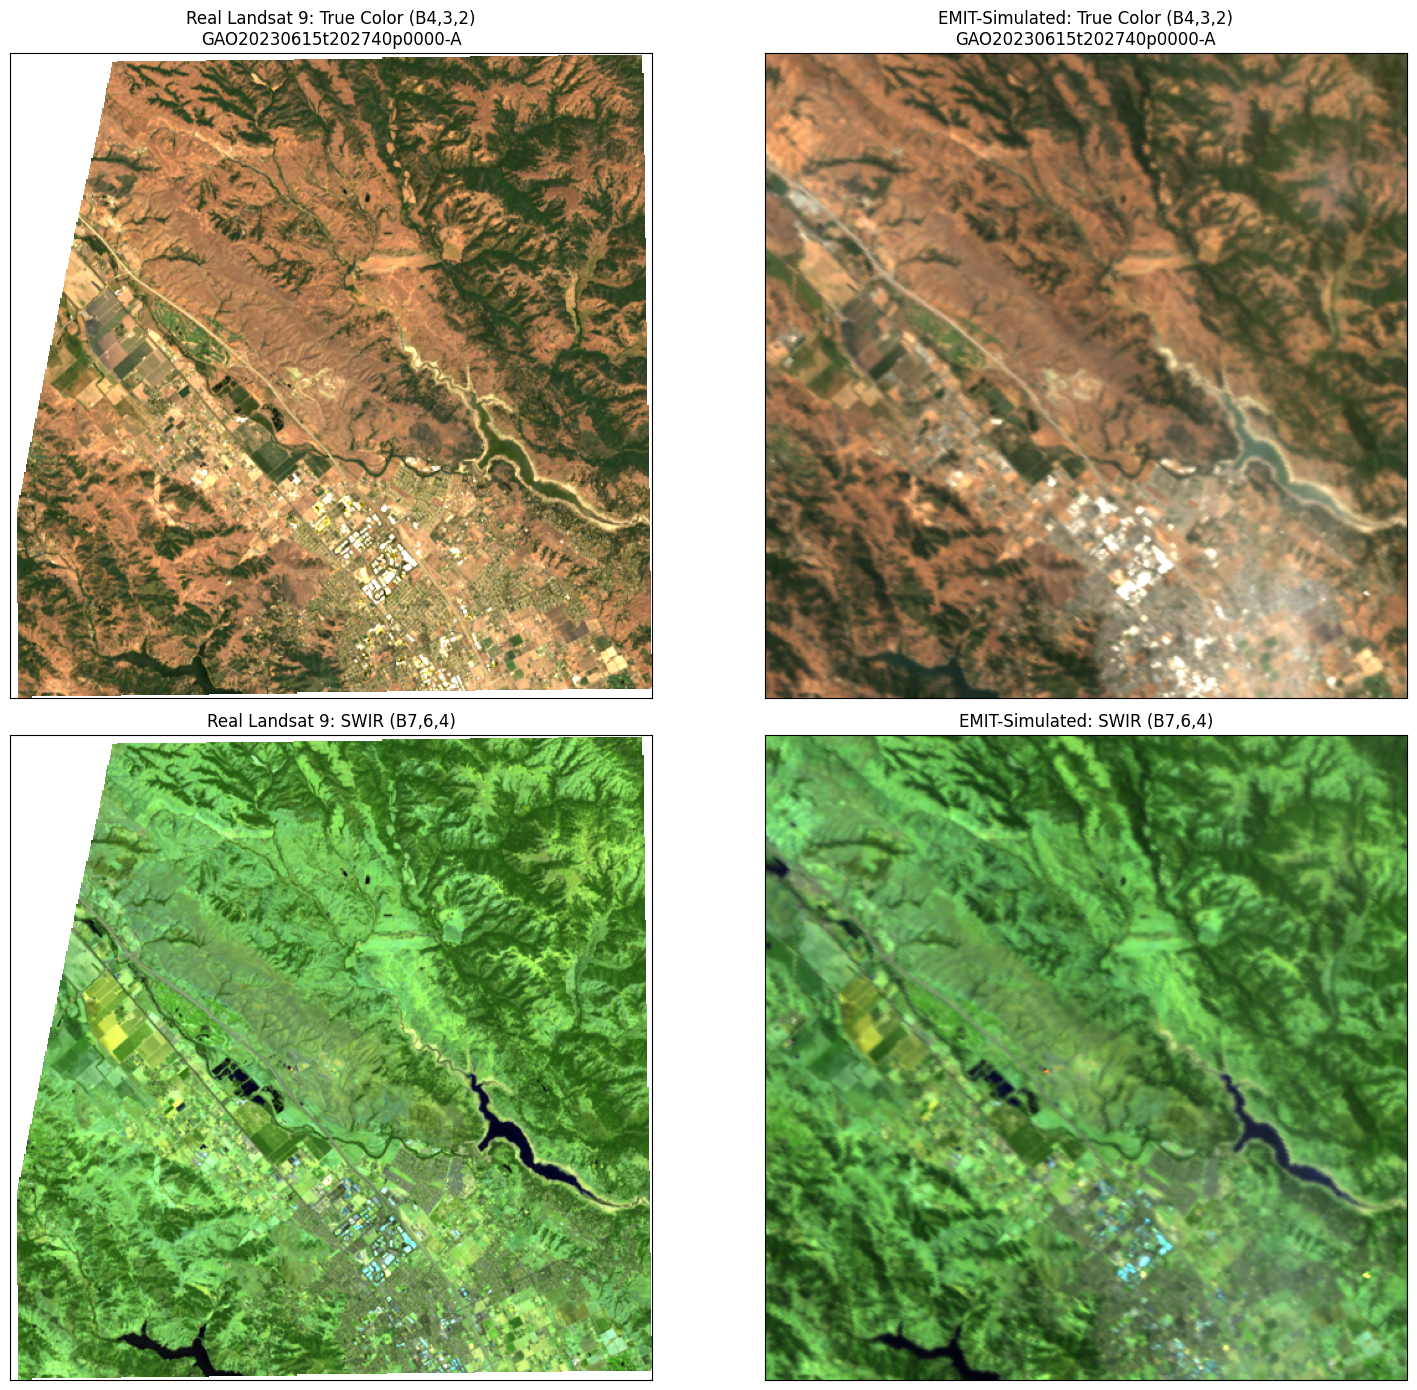

In [14]:
import numpy as np
import rioxarray
import matplotlib.pyplot as plt

def plot_comparison(plume_id, real_path, sim_path):
    # 1. 加载数据
    real_ds = rioxarray.open_rasterio(real_path)
    sim_ds = rioxarray.open_rasterio(sim_path)
    
    # 2. 预处理 Landsat (应用缩放系数并掩膜)
    # 假设 real_ds 是原始 DN 值，sim_ds 已经是反射率 (0-1)
    real_data = real_ds.values[:7, :, :].astype(np.float32)
    real_data = np.where(real_data > 0, real_data * 0.0000275 - 0.2, np.nan)
    real_data = np.clip(real_data, 0, 1)
    
    sim_data = sim_ds.values # 已经是反射率
    
    # 3. 设置绘图
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    
    # --- A. 可见光真彩色 (Band 4, 3, 2 -> RGB) ---
    # 使用 0-0.2 的拉伸增强细节
    real_rgb = np.moveaxis(real_data[[3, 2, 1]], 0, -1)
    sim_rgb = np.moveaxis(sim_data[[3, 2, 1]], 0, -1)
    
    axes[0, 0].imshow(np.clip(real_rgb / 0.2, 0, 1))
    axes[0, 0].set_title(f"Real Landsat 9: True Color (B4,3,2)\n{plume_id}", fontsize=12)
    
    axes[0, 1].imshow(np.clip(sim_rgb / 0.2, 0, 1))
    axes[0, 1].set_title(f"EMIT-Simulated: True Color (B4,3,2)\n{plume_id}", fontsize=12)
    
    # --- B. SWIR 短波红外 (Band 7, 6, 4 -> RGB) ---
    # Band 7(R), Band 6(G), Band 4(B) 是分析地表成分最常用的组合
    # 使用 0-0.4 的拉伸
    real_swir = np.moveaxis(real_data[[6, 5, 3]], 0, -1)
    sim_swir = np.moveaxis(sim_data[[6, 5, 3]], 0, -1)
    
    axes[1, 0].imshow(np.clip(real_swir / 0.4, 0, 1))
    axes[1, 0].set_title("Real Landsat 9: SWIR (B7,6,4)", fontsize=12)
    
    axes[1, 1].imshow(np.clip(sim_swir / 0.4, 0, 1))
    axes[1, 1].set_title("EMIT-Simulated: SWIR (B7,6,4)", fontsize=12)
    
    # 移除坐标轴提高视觉效果
    for ax in axes.flatten():
        ax.set_xticks([])
        ax.set_yticks([])
        
    plt.tight_layout()
    plt.show()

# --- 使用示例 ---
# 请替换为你本地实际的文件路径
plume_id_to_check = "GAO20230615t202740p0000-A"
real_l8_file = f"/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SR_by_gee/GAO20230615t202740p0000-A_l89_sr_LANDSAT_9_20230616T183912Z.tif"
sim_l8_file = f"./simulated_landsat_tifs/{plume_id_to_check}_emit_simulated.tif"

plot_comparison(plume_id_to_check, real_l8_file, sim_l8_file)

In [20]:
import numpy as np
import rioxarray
import matplotlib.pyplot as plt

def plot_spectral_profile_comparison(plume_id, real_path, sim_path):
    # 1. 加载对齐后的数据
    real_ds = rioxarray.open_rasterio(real_path)
    sim_ds = rioxarray.open_rasterio(sim_path)
    
    # 2. 预处理 Landsat (DN -> 反射率)
    real_l8_data = real_ds.values[:7].astype(np.float32)
    real_l8_data = np.where(real_l8_data > 0, real_l8_data * 0.0000275 - 0.2, np.nan)
    real_l8_data = np.clip(real_l8_data, 0, 1)
    
    # 模拟数据已经是反射率
    sim_l8_data = sim_ds.values
    
    # 3. 建立 SWIR 专用有效像素掩膜 (排除 Landsat 缺失区)
    # 确保 B6(index 5) 和 B7(index 6) 在两张图中都有值
    swir_mask = np.isfinite(real_l8_data[5]) & np.isfinite(real_l8_data[6]) & \
                np.isfinite(sim_l8_data[5]) & np.isfinite(sim_l8_data[6])
    
    y_idx, x_idx = np.where(swir_mask)
    
    if len(y_idx) > 0:
        # 随机选取一个有效的非空像素
        idx = np.random.randint(0, len(y_idx))
        py, px = y_idx[idx], x_idx[idx]

        # 定义 Landsat 的所有波段编号 (1-7)
        bands = np.arange(1, 8)
        
        plt.figure(figsize=(10, 6))
        
        # --- 绘制全波段曲线作为背景 (淡色显示) ---
        plt.plot(bands, real_l8_data[:, py, px], 'go-', alpha=0.2, label='Visible/NIR Bands (Real)')
        plt.plot(bands, sim_l8_data[:, py, px], 'ro--', alpha=0.2, label='Visible/NIR Bands (Sim)')
        
        # --- 高亮 SWIR 波段 (Band 6 & 7) ---
        # 注意索引 5: 是 Band 6 和 7
        plt.plot(bands[5:], real_l8_data[5:, py, px], 'go-', linewidth=3, markersize=12, 
                 markeredgecolor='k', label='SWIR Bands (Real Landsat 9)')
        plt.plot(bands[5:], sim_l8_data[5:, py, px], 'ro--', linewidth=3, markersize=12, 
                 markeredgecolor='k', label='SWIR Bands (EMIT-Simulated)')
        
        # 标注数值 (可选，方便直接看反射率差异)
        for i, b_idx in enumerate([5, 6]):
            plt.text(bands[b_idx], real_l8_data[b_idx, py, px], f"{real_l8_data[b_idx, py, px]:.3f}", 
                     va='bottom', ha='right', color='green', fontweight='bold')
            plt.text(bands[b_idx], sim_l8_data[b_idx, py, px], f"{sim_l8_data[b_idx, py, px]:.3f}", 
                     va='top', ha='left', color='red', fontweight='bold')

        plt.xlabel("Landsat Band Number", fontsize=12)
        plt.ylabel("Reflectance", fontsize=12)
        plt.xticks(bands)
        plt.ylim(0, max(np.nanmax(real_l8_data[:, py, px]), np.nanmax(sim_l8_data[:, py, px])) * 1.2)
        
        plt.legend(loc='upper left', frameon=True, shadow=True)
        plt.title(f"Spectral Profile Comparison at Valid Pixel (x={px}, y={py})\nID: {plume_id}", fontsize=14)
        plt.grid(True, linestyle=':', alpha=0.6)
        
        plt.tight_layout()
        plt.show()
    else:
        print(f"❌ 在 {plume_id} 的有效区域内未找到可采样的重叠像素点。")

# --- 使用示例 ---
plume_id_to_check = "GAO20230824t154540p0000-A"
# 替换为你的 Landsat 路径和生成的模拟路径
real_l8_file = f"/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_L89_L2SR_by_gee/GAO20230615t202740p0000-A_l89_sr_LANDSAT_9_20230616T183912Z.tif"
sim_l8_file = f"./simulated_landsat_tifs/{plume_id_to_check}_emit_simulated.tif"

plot_spectral_profile_comparison(plume_id_to_check, real_l8_file, sim_l8_file)

ValueError: operands could not be broadcast together with shapes (520,518) (526,525) 

In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio

csv_path = "preprocess_dataset_L89/merged_plumes_with_l89_sr.csv"
df = pd.read_csv(csv_path)

count_ok = 0
count_total = 0
bad_files = []

for path in df["l89_path"].dropna():
    if not os.path.exists(path):
        bad_files.append(path)
        continue

    try:
        with rasterio.open(path) as src:
            arr = src.read()  # (bands, H, W)
            nodata = src.nodata

        # 像素级缺失：NaN 或 nodata 或 所有波段为0
        nan_mask = np.isnan(arr)
        if nodata is None:
            nodata_mask = np.zeros_like(arr, dtype=bool)
        else:
            nodata_mask = (arr == nodata)

        zero_all_bands = (arr == 0).all(axis=0)  # (H, W)

        # 任何波段 NaN 或 nodata -> 像素缺失
        bad_any_band = (nan_mask | nodata_mask).any(axis=0)  # (H, W)

        missing_pixel = bad_any_band | zero_all_bands  # (H, W)

        total = missing_pixel.size
        missing = missing_pixel.sum()
        missing_rate = missing / total

        count_total += 1
        if missing_rate < 0.20:
            count_ok += 1
    except Exception:
        bad_files.append(path)

print(f"有效影像数: {count_total}")
print(f"缺失率 < 20% 的影像数: {count_ok}")
print(f"无法读取/不存在的影像数: {len(bad_files)}")


有效影像数: 2650
缺失率 < 20% 的影像数: 2571
无法读取/不存在的影像数: 0


In [7]:
import pandas as pd

# 1) 读数据（有经纬度 + 时间）
df = pd.read_csv("./merged_with_emit_tag.csv")

# 2) Permian basin bbox（请替换为你认可的范围）
# 示例：min_lon, max_lon, min_lat, max_lat
min_lon, max_lon = -105.5, -100.0
min_lat, max_lat =  30.0,  34.5

# 3) 时间过滤（2024-12-31 以前）
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce", utc=True)
time_mask = df["datetime"] < pd.Timestamp("2024-12-31T23:59:59Z")

# 4) 空间过滤（Permian basin）
space_mask = (
    (df["plume_longitude"] >= min_lon) & (df["plume_longitude"] <= max_lon) &
    (df["plume_latitude"]  >= min_lat) & (df["plume_latitude"]  <= max_lat)
)

count = (time_mask & space_mask).sum()
print("Permian basin 且 2024-12-31 以前的数据数量:", int(count))


Permian basin 且 2024-12-31 以前的数据数量: 550
